# Spotify Genre Prediction Using Machine Learning 

## Comparative Analysis of 114, 50, 25 and 10 Genre Classification

This project uses Machine Learning to predict Spotify music genres using audio features such as danceability, energy, loudness, tempo, acousticness, and valence.

The project compares model performance across:
- 114 Genre Classification
- Top 50 Genre Classification
- Top 25 Genre Classification
- Top 10 Genre Classification

The objective is to analyze how genre complexity affects machine learning accuracy and performance.

## Tools Used
- Python
- Pandas
- Matplotlib
- Seaborn
- Scikit-learn
- Jupyter Notebook

## Import Required Libraries

In [39]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

## Load Spotify Dataset

In [28]:
df = pd.read_csv("spotify.csv")

df.head()

,Unnamed: 0.1,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,0,0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,...,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,1,1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,...,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,2,2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,...,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,3,3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,...,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,4,4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,...,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic


## Data Cleaning

In [29]:
df = df.loc[:, ~df.columns.str.contains('^Unnamed')]

df.head()

,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,1,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,1,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,0,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,0,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,2,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic


## Dataset Information

In [40]:
print("Total Rows and Columns:", df.shape)

print("\nTotal Genres:", df['track_genre'].nunique())

print("\nGenre List:")
print(df['track_genre'].unique())

Total Rows and Columns: (114000, 20)

Total Genres: 114

Genre List:
<StringArray>
[   'acoustic',    'afrobeat',    'alt-rock', 'alternative',     'ambient',
       'anime', 'black-metal',   'bluegrass',       'blues',      'brazil',
 ...
     'spanish',       'study',     'swedish',   'synth-pop',       'tango',
      'techno',      'trance',    'trip-hop',     'turkish', 'world-music']
Length: 114, dtype: str


## Feature Selection

In [41]:
features = [
    'popularity',
    'duration_ms',
    'danceability',
    'energy',
    'key',
    'loudness',
    'mode',
    'speechiness',
    'acousticness',
    'instrumentalness',
    'liveness',
    'valence',
    'tempo',
    'time_signature'
]

print(features)

['popularity', 'duration_ms', 'danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'time_signature']


## 114 Genre Classification

In [52]:
X = df[features]

y = df['track_genre']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

model_114 = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model_114.fit(X_train, y_train)

y_pred_114 = model_114.predict(X_test)

accuracy_114 = accuracy_score(y_test, y_pred_114)

print("114 Genre Accuracy:", accuracy_114)

114 Genre Accuracy: 0.32092105263157894


### Insight

The 114-genre classification problem produced lower accuracy because the model had to distinguish between a very large number of music genres with overlapping audio characteristics. Many genres share similar musical patterns, making classification more complex.

## Top 50 Genre Classification

In [53]:
top_50 = df['track_genre'].value_counts().nlargest(50).index

df_50 = df[df['track_genre'].isin(top_50)]

X = df_50[features]

y = df_50['track_genre']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

model_50 = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model_50.fit(X_train, y_train)

y_pred_50 = model_50.predict(X_test)

accuracy_50 = accuracy_score(y_test, y_pred_50)

print("Top 50 Genre Accuracy:", accuracy_50)

Top 50 Genre Accuracy: 0.438


### Insight

Reducing the number of genres to 50 improved the model accuracy. With fewer target classes, the model was able to learn genre patterns more effectively and reduce classification confusion.

## Top 25 Genre Classification

In [44]:
top_25 = df['track_genre'].value_counts().nlargest(25).index

df_25 = df[df['track_genre'].isin(top_25)]

X = df_25[features]

y = df_25['track_genre']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

model_25 = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model_25.fit(X_train, y_train)

y_pred_25 = model_25.predict(X_test)

accuracy_25 = accuracy_score(y_test, y_pred_25)

print("Top 25 Genre Accuracy:", accuracy_25)

Top 25 Genre Accuracy: 0.5928


### Insight

The Top 25 Genre model achieved significantly higher accuracy because the classification complexity decreased further. The model could better separate genre boundaries and identify audio feature patterns.

## Top 10 Genre Classification

In [45]:
top_10 = df['track_genre'].value_counts().nlargest(10).index

df_10 = df[df['track_genre'].isin(top_10)]

X = df_10[features]

y = df_10['track_genre']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

model_10 = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model_10.fit(X_train, y_train)

y_pred_10 = model_10.predict(X_test)

accuracy_10 = accuracy_score(y_test, y_pred_10)

print("Top 10 Genre Accuracy:", accuracy_10)

Top 10 Genre Accuracy: 0.64


### Insight

The Top 10 Genre model achieved the highest accuracy of 64%. With fewer classes and reduced overlap between genres, the Random Forest model performed more effectively in predicting music genres.

The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.


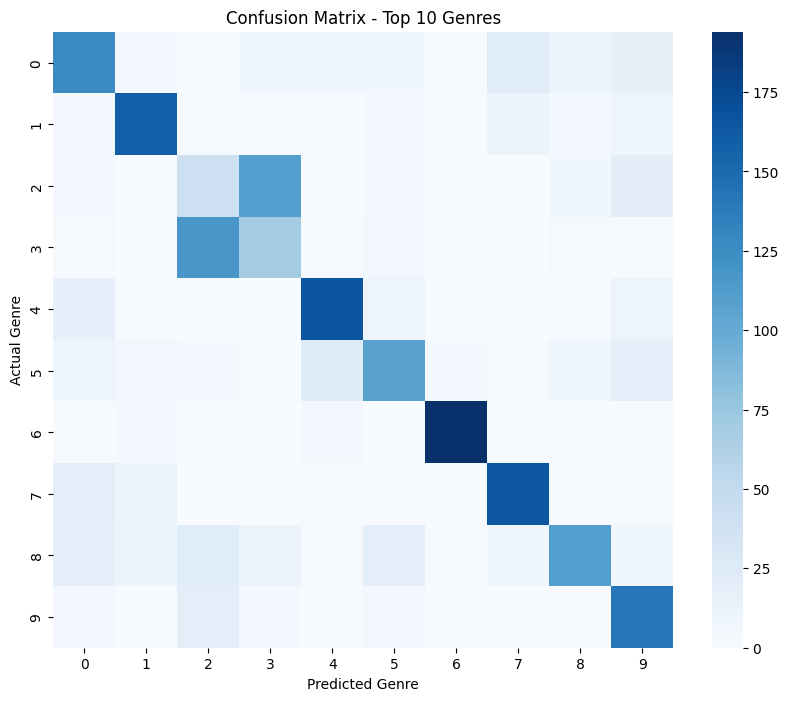

In [46]:
cm = confusion_matrix(y_test, y_pred_10)

plt.figure(figsize=(10,8))

sns.heatmap(cm, cmap='Blues')

plt.title('Confusion Matrix - Top 10 Genres')

plt.xlabel('Predicted Genre')

plt.ylabel('Actual Genre')

plt.show()

## Model Evaluation Visualization

* Confusion Matrix visualization was primarily used for the Top 10 Genre Classification model because it provides a cleaner and more interpretable representation of predictions.

* For higher-class classification problems such as 50 and 114 genres, confusion matrices become extremely large and difficult to interpret visually.

* ROC Curves were not used because multiclass classification involving a large number of genres creates highly complex ROC visualizations that are less meaningful for this project.

* Therefore, accuracy comparison and confusion matrix visualization were selected as the most suitable evaluation techniques for this multiclass genre prediction system.

## Accuracy Comparison of Genre Classification Models

In [47]:
comparison_df = pd.DataFrame({
    'Number of Genres': ['114 Genres', '50 Genres', '25 Genres', '10 Genres'],
    'Accuracy': [0.3209, 0.4380, 0.5928, 0.6400]
})

comparison_df

,Number of Genres,Accuracy
0,114 Genres,0.3209
1,50 Genres,0.4380
2,25 Genres,0.5928
3,10 Genres,0.6400


## Accuracy Comparison Graph

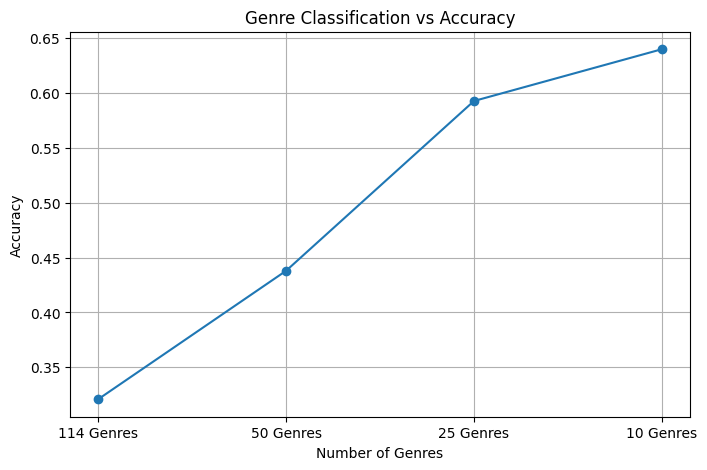

In [48]:
genre_counts = ['114 Genres', '50 Genres', '25 Genres', '10 Genres']

accuracies = [0.3209, 0.4380, 0.5928, 0.6400]

plt.figure(figsize=(8,5))

plt.plot(genre_counts, accuracies, marker='o')

plt.title('Genre Classification vs Accuracy')

plt.xlabel('Number of Genres')

plt.ylabel('Accuracy')

plt.grid(True)

plt.show()

## Conclusion

This project successfully implemented Machine Learning models to predict Spotify music genres using audio features such as danceability, energy, loudness, tempo, and valence.

Multiple classification experiments were performed using:
- 114 Genres
- Top 50 Genres
- Top 25 Genres
- Top 10 Genres

The project demonstrated that reducing the number of target classes improves model accuracy.

### Final Results

| Genre Classes | Accuracy |
|---|---|
| 114 Genres | 32.09% |
| 50 Genres | 43.8% |
| 25 Genres | 59.28% |
| 10 Genres | 64.0% |

The Random Forest Classifier achieved the highest performance in the Top 10 Genre Classification model.

The project also included:
- Data Cleaning
- Feature Selection
- Supervised Learning
- Model Evaluation
- Confusion Matrix Visualization
- Comparative Accuracy Analysis

This project provided practical experience in predictive modeling, multiclass classification, and machine learning evaluation techniques.

## Future Improvements

The project can be further improved using:
- Advanced Machine Learning algorithms such as XGBoost or Neural Networks
- Hyperparameter tuning
- Feature engineering techniques
- Deep Learning approaches for audio classification
- Real-time music genre prediction systems